<a href="https://colab.research.google.com/github/KeshavaOfficial/DataScience-Projects/blob/Projects/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/mushroom.csv')

In [4]:
df

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,1160,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,411,bell,smooth,white,no,pungent,free,close,narrow,orange,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199


In [5]:
df.columns

Index(['Unnamed: 0', 'cap_shape', 'cap_surface', 'cap_color', 'bruises',
       'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='object')

droping un Important features like Name


In [6]:
df = df.drop(columns = 'Unnamed: 0')

#Let visualize the data and find any outliers are present

In [8]:
df.columns

Index(['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor',
       'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='object')

df.columns

<Axes: ylabel='Count'>

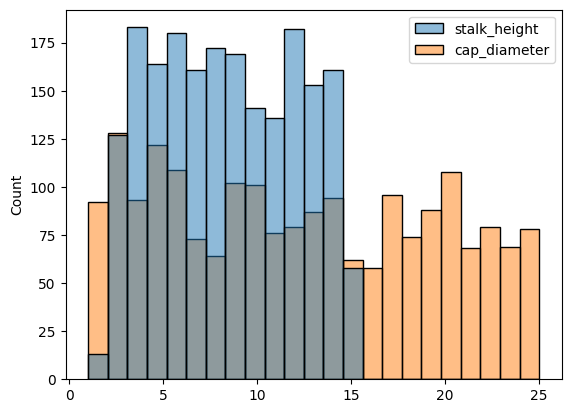

In [7]:
sns.histplot(df)

<Axes: >

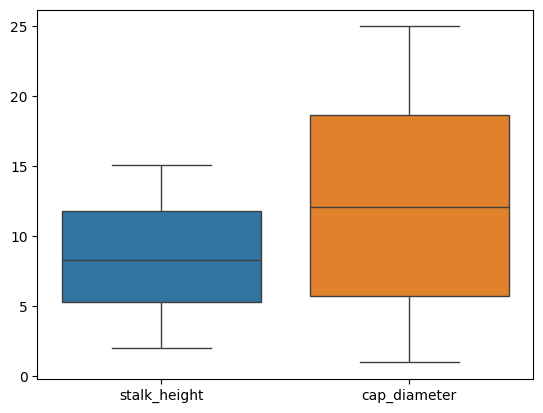

In [9]:
sns.boxplot(df)

#Data mostly in Categorical Data So we need to Encode the Data and then we need to visualize so that we find Outliers


In [10]:
y = df["class"]

In [35]:
x = df[['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor',
        'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
        'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
        'stalk_surface_below_ring', 'stalk_color_above_ring',
        'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
        'ring_type', 'spore_print_color', 'population', 'habitat',
        'stalk_height', 'cap_diameter']]


#Assuming Class as Y or dependent Variable

In [36]:
x.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,brown,universal,brown,two,sheathing,brown,numerous,waste,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,gray,universal,yellow,two,sheathing,purple,abundant,waste,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,pink,partial,yellow,two,cobwebby,green,clustered,grasses,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,white,universal,white,none,none,yellow,clustered,urban,14.037532,12.545245


In [37]:
y.head()

,class
0,poisonous
1,edible
2,poisonous
3,poisonous
4,poisonous


#lets encode all the data


In [38]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

X_encoded = encoder.fit_transform(x)
X_encoded = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(x.columns))

In [40]:
X = X_encoded

In [41]:
Y = y

#need to encode the Dependent feature


In [42]:
from operator import le
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y = le.fit_transform(Y)

In [44]:
Y = pd.DataFrame(Y, columns=['class'])

In [46]:
Y.head(30)

,class
0,1
1,0
2,1
3,1
4,1
5,1
6,1
7,1
8,0
9,1


#Finding the mushroom is POISONOUS OR EDIBLE using the data, we encode our dependent and Independent Values now lets  Visualize the data and Standardize the Independent Features


In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#SVC kernel as Linear

In [51]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[[ 87  46]
 [  0 267]]
              precision    recall  f1-score   support

           0       1.00      0.65      0.79       133
           1       0.85      1.00      0.92       267

    accuracy                           0.89       400
   macro avg       0.93      0.83      0.86       400
weighted avg       0.90      0.89      0.88       400

Accuracy: 0.885


#kernel as POLY

In [52]:
from sklearn.svm import SVC
svc = SVC(kernel= 'poly')
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[[ 41  92]
 [  0 267]]
              precision    recall  f1-score   support

           0       1.00      0.31      0.47       133
           1       0.74      1.00      0.85       267

    accuracy                           0.77       400
   macro avg       0.87      0.65      0.66       400
weighted avg       0.83      0.77      0.73       400

Accuracy: 0.77


#kernel as RBF

In [83]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', C= 1, gamma=0.001)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[[ 87  46]
 [  0 267]]
              precision    recall  f1-score   support

           0       1.00      0.65      0.79       133
           1       0.85      1.00      0.92       267

    accuracy                           0.89       400
   macro avg       0.93      0.83      0.86       400
weighted avg       0.90      0.89      0.88       400

Accuracy: 0.885


#kernel as SIGMOID and Regularization parameter is 1.3 so it is not a over fitting and under fitting

In [82]:
from sklearn.svm import SVC
svc = SVC(kernel='sigmoid', C= 1, gamma=0.001 )
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[[ 87  46]
 [  0 267]]
              precision    recall  f1-score   support

           0       1.00      0.65      0.79       133
           1       0.85      1.00      0.92       267

    accuracy                           0.89       400
   macro avg       0.93      0.83      0.86       400
weighted avg       0.90      0.89      0.88       400

Accuracy: 0.885


#For all the Kernels the ACCURACY is almost same

#GridsearchCV for RBF kernel

In [76]:
from sklearn.model_selection import GridSearchCV


In [77]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf'],
    'gamma': [0.001, 0.01, 0.1, 1]
}


In [78]:

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf']})

In [80]:
print(grid.best_params_)


{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}


#RandomSearchCV with RBF kernel

In [81]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf'],
    'gamma': [0.001, 0.01, 0.1, 1]
}

random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=10, cv=5)
random_search.fit(X_train, y_train)

print(random_search.best_params_)


{'kernel': 'rbf', 'gamma': 1, 'C': 100}


#SVM Strengths & Weaknesses for Mushroom Dataset
Strengths: Handles high-dimensional data well, robust to outliers, supports non-linear classification via kernels, and can effectively separate edible vs. poisonous mushrooms.
Weaknesses: Computationally expensive for large datasets, requires careful parameter tuning, lacks interpretability, and struggles with sparse one-hot encoded categorical data.

#Practical Implications of SVM
Used in bioinformatics (cancer detection), spam detection, fraud detection, image classification, and sentiment analysis due to its strong generalization and robustness in complex datasets.